Informations sur l'étudiant:

*   Nom : FANOMEZANTSOA
*   Prénom(s) : Maminirina Aina Fitiavana
*   Classe : ESIIA4
*   Numéro : 08


1.  Chargement et inspection des données

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
# Configuration graphique
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)
print("Bibliothèques importées avec succès")

# Charger le jeu de données California Housing
housing = fetch_california_housing(as_frame=True)
df = housing.frame
print(f"Dimensions du dataset : {df.shape[0]} lignes × {df.shape[1]} colonnes")
print(f"\nVariable cible : MedHouseVal (valeur médiane du logement en centaines de milliers de $)")
print(f"\nDescription des variables :")
print("-" * 60)
descriptions = {
'MedInc': 'Revenu médian du quartier',
'HouseAge': 'Âge médian des logements',
'AveRooms': 'Nombre moyen de pièces par logement',
'AveBedrms': 'Nombre moyen de chambres par logement',
'Population': 'Population du quartier',
'AveOccup': 'Nombre moyen d\'occupants par logement',
'Latitude': 'Latitude géographique',
'Longitude': 'Longitude géographique',
'MedHouseVal': 'Prix médian du logement (cible)'
}
for col, desc in descriptions.items():
    print(f" {col:15s} → {desc}")



Bibliothèques importées avec succès
Dimensions du dataset : 20640 lignes × 9 colonnes

Variable cible : MedHouseVal (valeur médiane du logement en centaines de milliers de $)

Description des variables :
------------------------------------------------------------
 MedInc          → Revenu médian du quartier
 HouseAge        → Âge médian des logements
 AveRooms        → Nombre moyen de pièces par logement
 AveBedrms       → Nombre moyen de chambres par logement
 Population      → Population du quartier
 AveOccup        → Nombre moyen d'occupants par logement
 Latitude        → Latitude géographique
 Longitude       → Longitude géographique
 MedHouseVal     → Prix médian du logement (cible)


In [12]:
# Afficher les premières lignes avec .head()
# pour avoir un aperçu visuel des données
df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [13]:
# Utiliser .info() pour vérifier les types de colonnes
# et détecter les éventuelles valeurs manquantes
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   MedInc       20640 non-null  float64
 1   HouseAge     20640 non-null  float64
 2   AveRooms     20640 non-null  float64
 3   AveBedrms    20640 non-null  float64
 4   Population   20640 non-null  float64
 5   AveOccup     20640 non-null  float64
 6   Latitude     20640 non-null  float64
 7   Longitude    20640 non-null  float64
 8   MedHouseVal  20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB


In [14]:
# Utiliser .describe() pour obtenir les statistiques descriptives :
# moyenne, écart-type, min, max, quartiles de chaque colonne
df.describe()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


2. Nettoyage des données

In [28]:
# Vérifier les valeurs manquantes avec .isnull().sum()
# Si présentes : soit les supprimer (.dropna), soit les imputer (.fillna)

champ_null = df.isnull().sum()
print("Valeurs manquantes:\n", champ_null)

# Si des valeurs manquantes sont présentes
if champ_null.sum() > 0:
    # Option 1 : supprimer les lignes contenant des NaN
    df = df.dropna()

    # Option 2 : imputation par la moyenne
    # df = df.fillna(df.mean())
else:
    print("Aucune valeur manquante détectée dans le dataset")


Valeurs manquantes:
 MedInc         0
HouseAge       0
AveRooms       0
AveBedrms      0
Population     0
AveOccup       0
Latitude       0
Longitude      0
MedHouseVal    0
dtype: int64
Aucune valeur manquante détectée dans le dataset


In [29]:
# Vérifier et supprimer les doublons avec .duplicated() et .drop_duplicates()
df = df.drop_duplicates()

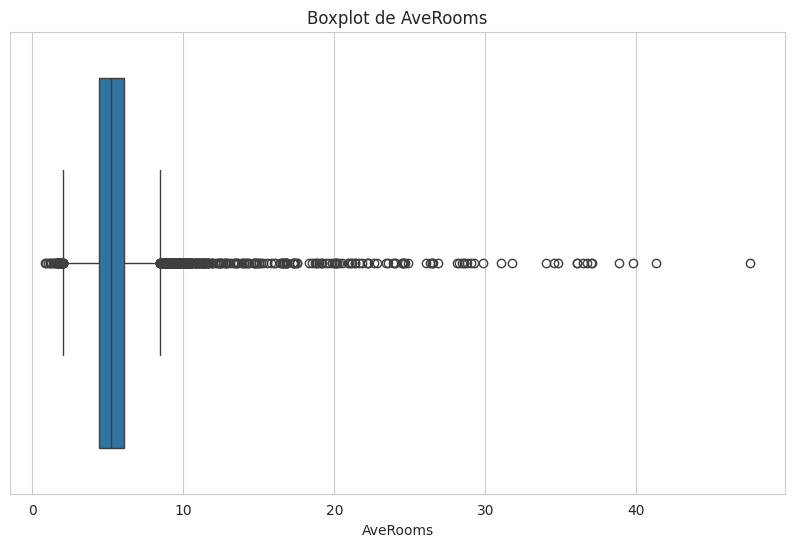

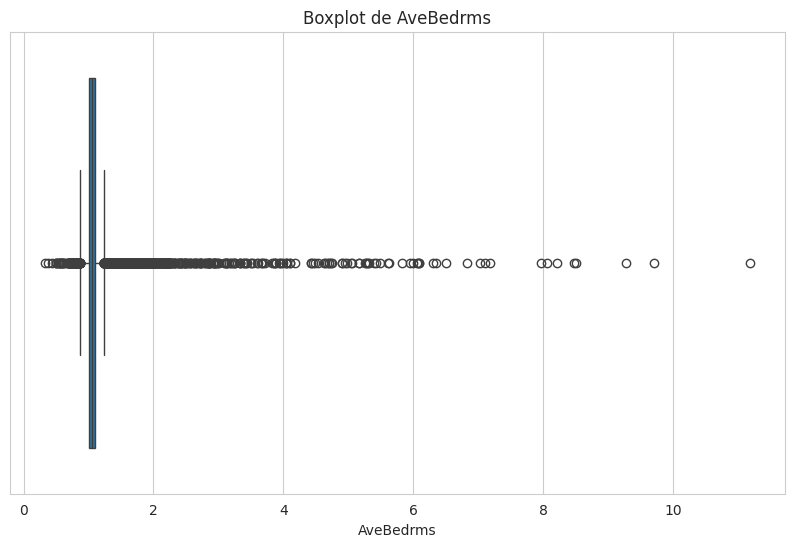

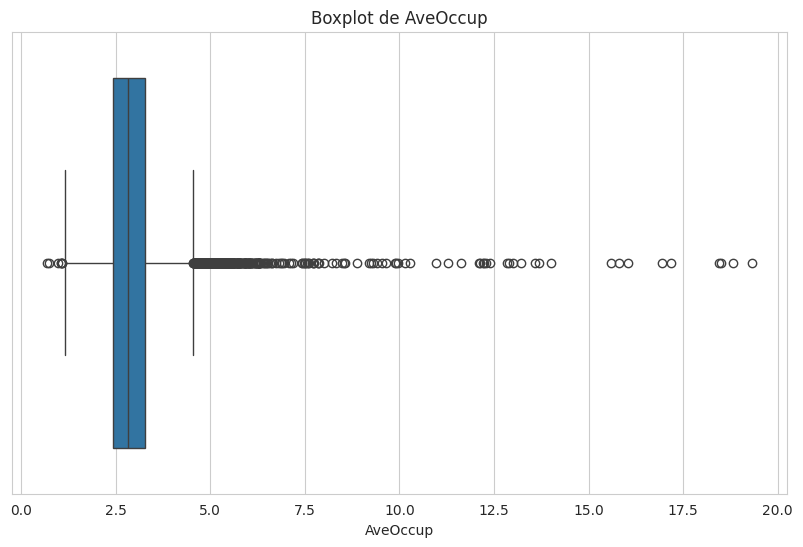

In [19]:
# Détecter les valeurs aberrantes (outliers) à l'aide de boxplots
# Les boxplots montrent visuellement la distribution et les points extrêmes
# Filtrer les outliers extrêmes pour AveRooms, AveBedrms et AveOccup
# On fixe des seuils raisonnables (ex: AveRooms < 50, AveOccup < 20)
# pour éviter que ces valeurs extrêmes faussent le modèle

df = df[
    (df["AveRooms"] < 50) &
    (df["AveBedrms"] < 20) &
    (df["AveOccup"] < 20)
]

print(f"Dimensions après nettoyage : {df.shape}")
# Sélection des variables numériques à analyser
variables_outliers = ["AveRooms", "AveBedrms", "AveOccup"]

# Création des boxplots
for var in variables_outliers:
    plt.figure()
    sns.boxplot(x=df[var])
    plt.title(f"Boxplot de {var}")
    plt.show()



3. Analyse exploratoire (EDA)

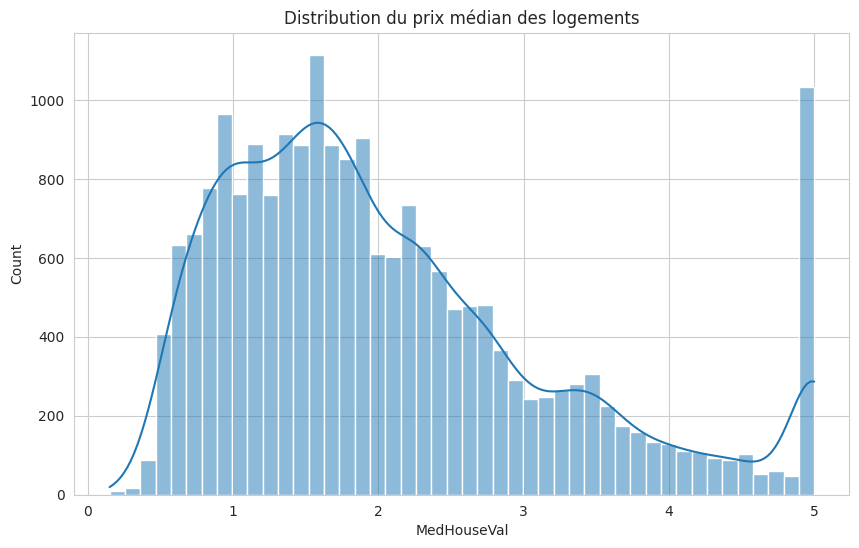

In [20]:
# Tracer la distribution de la variable cible (MedHouseVal)
# avec un histogramme + courbe de densité (kde)

sns.histplot(df["MedHouseVal"], kde=True)
plt.title("Distribution du prix médian des logements")
plt.show()

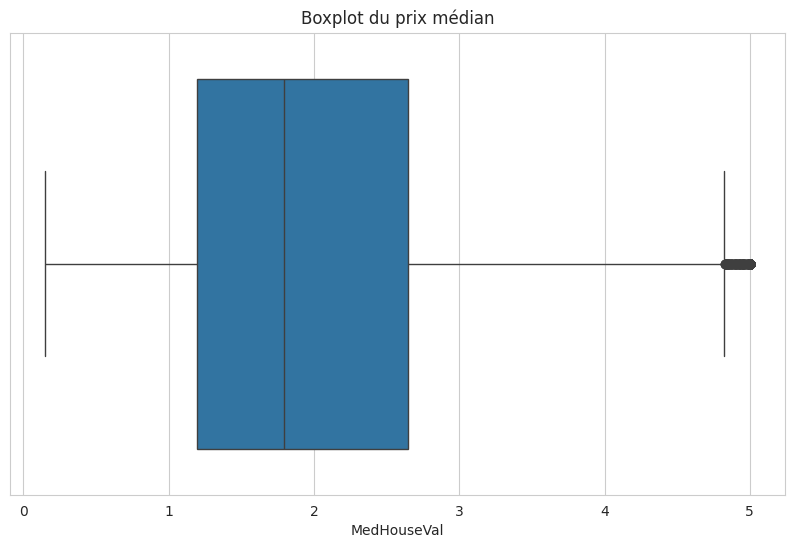

In [21]:
# et un boxplot pour repérer la médiane et les extrêmes
sns.boxplot(x=df["MedHouseVal"])
plt.title("Boxplot du prix médian")
plt.show()


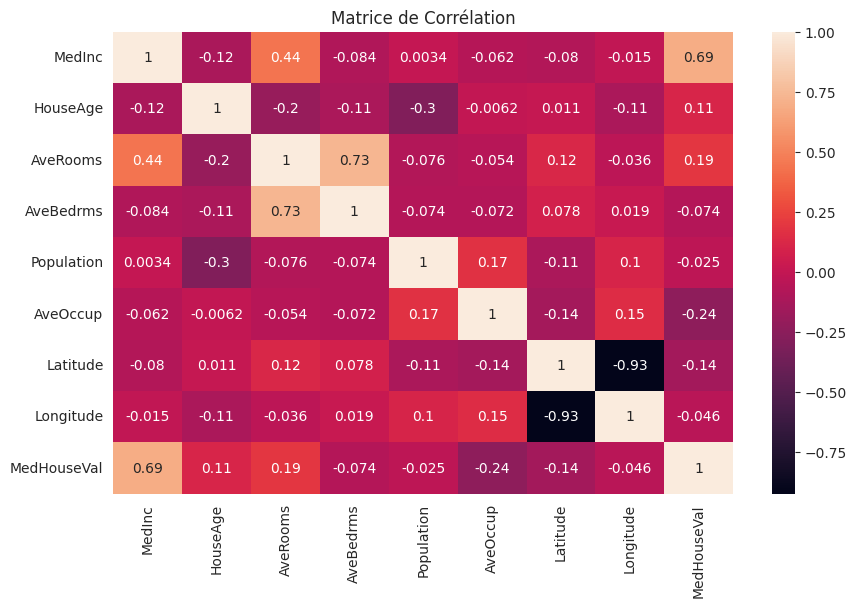

In [30]:
# Calculer et afficher la matrice de corrélation sous forme de heatmap
# Cela permet d'identifier quelles variables sont le plus liées au prix :
# - corrélation proche de +1 → relation positive forte
# - corrélation proche de -1 → relation négative forte
# - corrélation proche de 0 → pas de relation linéaire
correlation = df.corr()
heatmap = sns.heatmap(correlation, annot=True)
plt.title('Matrice de Corrélation')
plt.show()

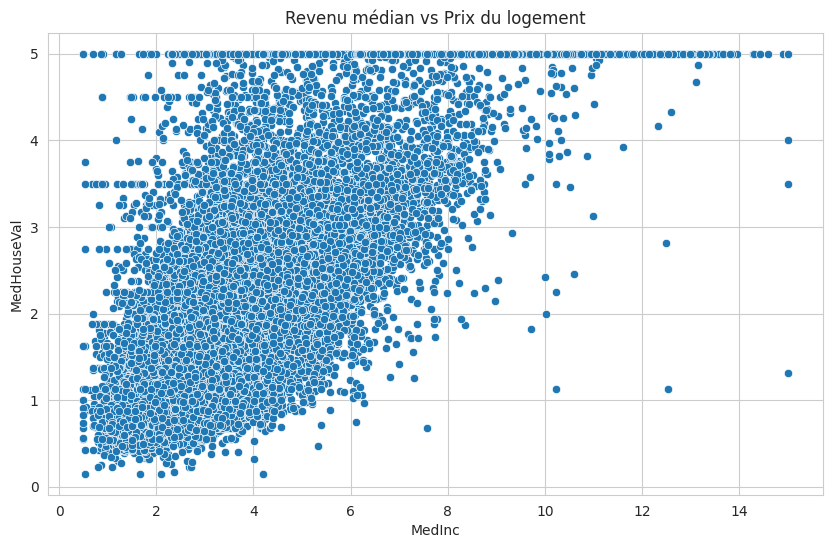

In [24]:
# Scatter plots : croiser les variables les plus corrélées avec la cible
# Ex : MedInc vs MedHouseVal → on s'attend à une relation positive forte
# (plus le revenu est élevé, plus le logement est cher)

sns.scatterplot(x="MedInc", y="MedHouseVal", data=df)
plt.title("Revenu médian vs Prix du logement")
plt.show()


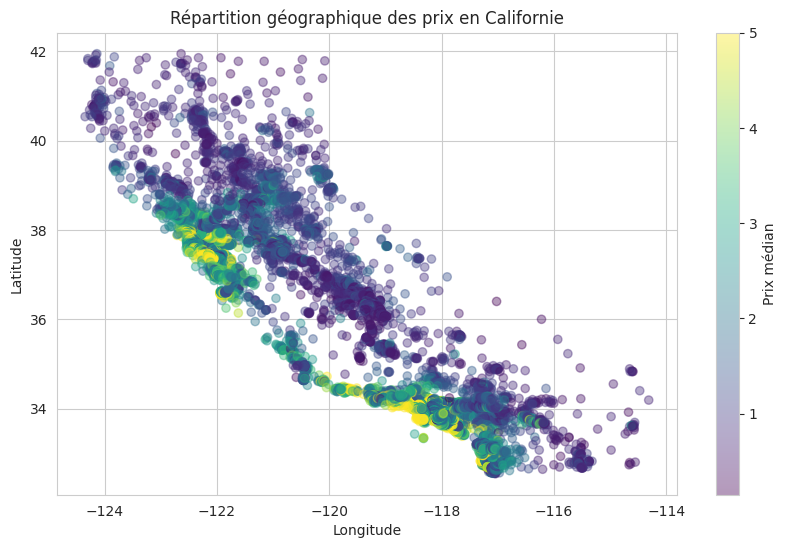

In [32]:
# Carte géographique : afficher chaque quartier (Latitude, Longitude)
# coloré selon le prix médian, pour visualiser la répartition spatiale
# des prix en Californie (zones côtières = plus cher)
plt.scatter(
    df["Longitude"],
    df["Latitude"],
    c=df["MedHouseVal"],
    cmap="viridis",
    alpha=0.4
)
plt.colorbar(label="Prix médian")
plt.title("Répartition géographique des prix en Californie")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.show()



 4. Ingénierie des variables

In [33]:
# Créer de nouvelles variables dérivées, par exemple :
# PiecesParChambre = AveRooms / AveBedrms (ratio pièces/chambres)
# PopParLogement = Population / AveOccup (estimation du nb de logements)
# Ces nouvelles features peuvent capturer des informations supplémentaires

df["PiecesParChambre"] = df["AveRooms"] / df["AveBedrms"]
df["PopParLogement"] = df["Population"] / df["AveOccup"]


In [ ]:
# Séparer les données en :
# X = variables explicatives (features) → les 10 colonnes d'entrée
# y = variable cible → MedHouseVal (le prix à prédire)

X = df.drop("MedHouseVal", axis=1)
y = df["MedHouseVal"]

5. Séparation entraînement / test

In [ ]:
# Diviser X et y en deux sous-ensembles avec train_test_split :
# - 80% pour l'entraînement (le modèle apprend sur ces données)
# - 20% pour le test (on évalue la qualité des prédictions)
# Le paramètre random_state=42 garantit la reproductibilité

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Taille de l'entraînement : {X_train.shape[0]} quartiers")
print(f"Taille du test : {X_test.shape[0]} quartiers")

6. Construction du modèle de régression linéaire

In [ ]:
# Instancier LinearRegression() et entraîner avec .fit(X_train, y_train)
# Le modèle calcule les coefficients β optimaux en minimisant
# la somme des carrés des erreurs (méthode des moindres carrés)
# Afficher :
# - model.intercept_ → l'ordonnée à l'origine (β₀)
# - model.coef_ → les coefficients (β₁, β₂, ..., βₙ)
# Un coefficient positif = la variable augmente le prix
# Un coefficient négatif = la variable diminue le prix

model = LinearRegression()
model.fit(X_train, y_train)
print("Ordonnée à l'origine (β0) :", model.intercept_)
coeffs = pd.DataFrame({
    "Variable": X.columns,
    "Coefficient": model.coef_
}).sort_values(by="Coefficient", ascending=False)

coeffs



7. Prédiction et évaluation

In [ ]:
# Prédire les prix sur l'ensemble de test avec model.predict(X_test)
# Puis calculer les métriques d'évaluation :
#
# MSE = moyenne des (réel - prédit)² → erreur quadratique moyenne
# RMSE = √MSE → plus interprétable (même unité que y)
# MAE = moyenne des |réel - prédit| → erreur absolue moyenne
# R² = 1 - (SS_res / SS_tot) → proportion de variance expliquée
#
# R² = 1.0 → prédiction parfaite
# R² = 0.0 → le modèle ne fait pas mieux que la moyenne

y_pred = model.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"MSE  : {mse:.3f}")
print(f"RMSE : {rmse:.3f}")
print(f"MAE  : {mae:.3f}")
print(f"R²   : {r2:.3f}")


8. Visualisation des résultats

In [ ]:
# Graphique 1 : Valeurs réelles vs Prédites
# Un scatter plot avec la ligne diagonale (prédiction parfaite)
# Plus les points sont proches de la diagonale, meilleur est le modèle

plt.scatter(y_test, y_pred, alpha=0.4)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         "r--")
plt.xlabel("Valeurs réelles")
plt.ylabel("Valeurs prédites")
plt.title("Réel vs Prédit")
plt.show()


# Graphique 2 : Analyse des résidus (résidu = réel - prédit)
# a) Histogramme des résidus → devrait suivre une distribution normale centrée sur 0
# b) Résidus vs Prédictions → les points doivent être dispersés aléatoirement
# (un pattern visible indiquerait que le modèle rate quelque chose)

residus = y_test - y_pred

sns.histplot(residus, kde=True)
plt.title("Distribution des résidus")
plt.show()

plt.scatter(y_pred, residus, alpha=0.4)
plt.axhline(0, color="red", linestyle="--")
plt.xlabel("Valeurs prédites")
plt.ylabel("Résidus")
plt.title("Résidus vs Prédictions")
plt.show()


# Graphique 3 : Barplot des coefficients du modèle
# Permet de visualiser l'importance relative de chaque variable :
# 🟢 Coefficient positif = contribue à augmenter le prix
# 🔴 Coefficient négatif = contribue à diminuer le prix

sns.barplot(
    x="Coefficient",
    y="Variable",
    data=coeffs
)
plt.title("Importance des variables")
plt.show()



9. Export des résultats


In [ ]:
# Créer un DataFrame de résultats contenant :
# - les features du test
# - le prix réel
# - le prix prédit
# - le résidu (écart)
# - l'erreur en pourcentage
# Puis exporter en CSV avec .to_csv("resultats_regression.csv")
resultats = X_test.copy()
resultats["Prix_reel"] = y_test
resultats["Prix_predit"] = y_pred
resultats["Residus"] = residus
resultats["Erreur_%"] = (residus / y_test) * 100

resultats.to_csv("resultats_regression.csv", index=False)
